# Bowls and Euros

In [1]:
# If we're running on Colab, install empiricaldist
# https://pypi.org/project/empiricaldist/

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install empiricaldist

In [2]:
# Get utils.py

import os

if not os.path.exists('utils.py'):
    !wget https://github.com/AllenDowney/ThinkBayes2/raw/master/soln/utils.py

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import decorate

In [22]:
from empiricaldist import Pmf

xs = np.linspace(0, 1, 101)
prior = Pmf(1/101, xs)

from scipy.stats import binom

likelihood = binom.pmf(k=6, n=10, p=xs)
posterior = prior * likelihood
posterior /= posterior.sum()

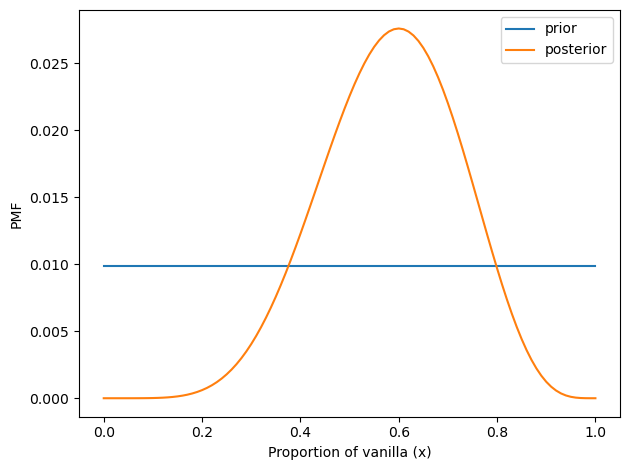

In [25]:
prior.plot(label='prior')
posterior.plot(label='posterior')
decorate(xlabel='Proportion of vanilla (x)', ylabel='PMF')

In [26]:
xs = np.linspace(0, 1, 101)
prior = Pmf(1/101, xs)

likelihood = binom.pmf(k=140, n=250, p=xs)
posterior = prior * likelihood
posterior /= posterior.sum()


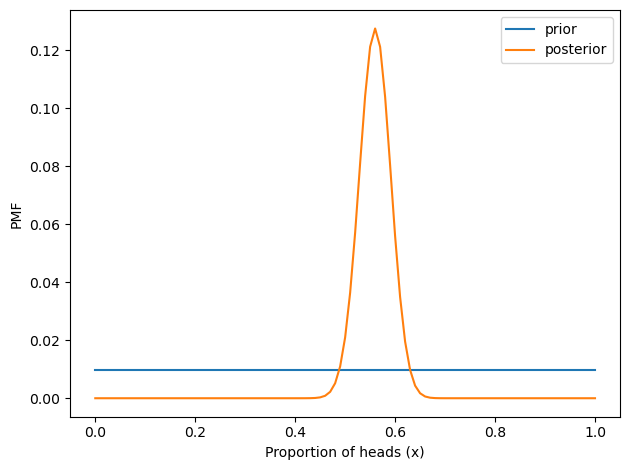

In [27]:
prior.plot(label='prior')
posterior.plot(label='posterior')
decorate(xlabel='Proportion of heads (x)', ylabel='PMF')

In [30]:
ramp_up = np.arange(50)
ramp_down = np.arange(50, -1, -1)

a = np.append(ramp_up, ramp_down)

triangle = Pmf(a, xs)
triangle.normalize()

2500

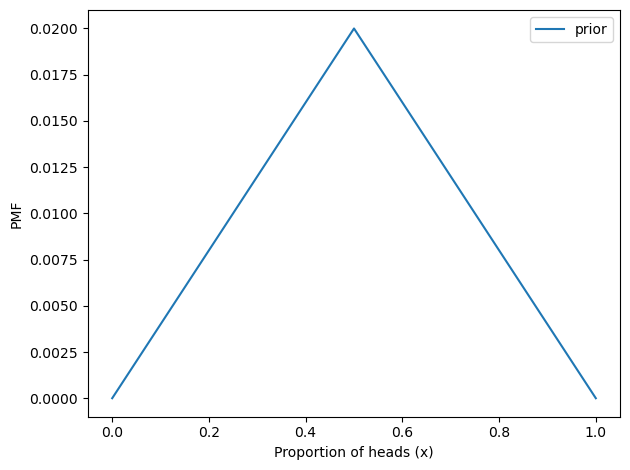

In [34]:
triangle.plot(label='prior')
decorate(xlabel='Proportion of heads (x)', ylabel='PMF')

In [31]:
posterior2 = triangle * likelihood
posterior2 /= posterior2.sum()

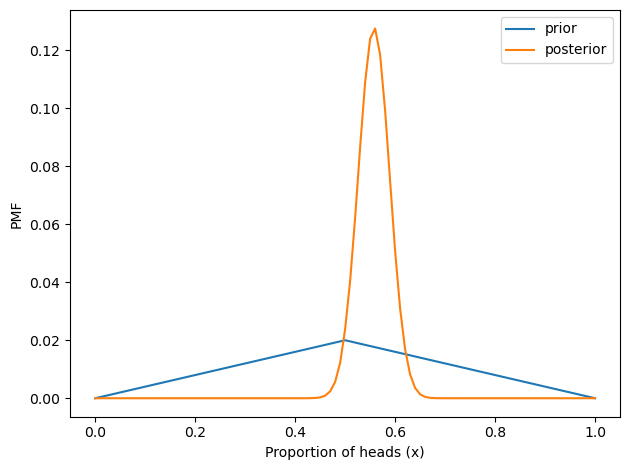

In [33]:
triangle.plot(label='prior')
posterior2.plot(label='posterior')
decorate(xlabel='Proportion of heads (x)', ylabel='PMF')

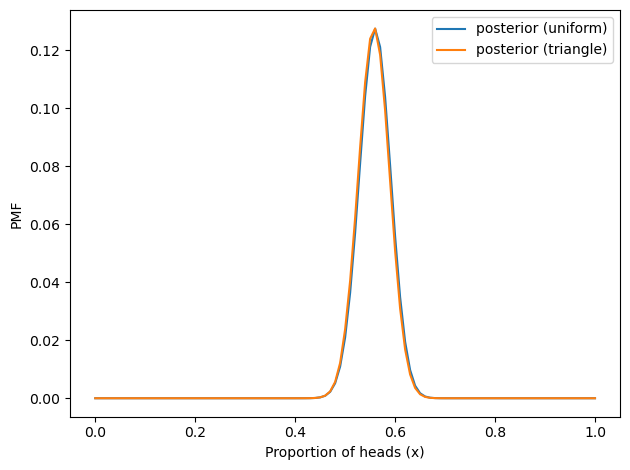

In [37]:
posterior.plot(label='posterior (uniform)')
posterior2.plot(label='posterior (triangle)')
decorate(xlabel='Proportion of heads (x)', ylabel='PMF')

## The Rookie Problem

In [39]:
xs = np.linspace(0, 1, 101)
prior = Pmf(1/101, xs)

likelihood = binom.pmf(k=3, n=3, p=xs)
posterior = prior * likelihood
posterior /= posterior.sum()

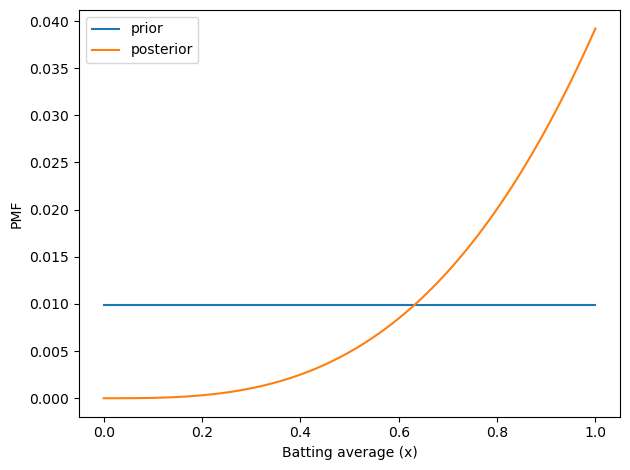

In [40]:
prior.plot(label='prior')
posterior.plot(label='posterior')
decorate(xlabel='Batting average (x)', ylabel='PMF')

In [41]:
posterior.mean()

0.8039734653465347

Use pseudocounts to construct a prior

In [49]:
xs = np.linspace(0, 1, 101)
prior = Pmf(1/101, xs)

likelihood = binom.pmf(k=25, n=75, p=xs)
posterior = prior * likelihood
posterior /= posterior.sum()

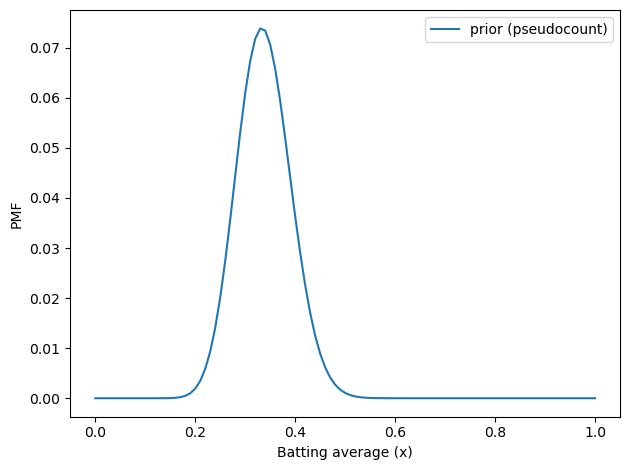

In [50]:
prior2 = posterior
prior2.plot(label='prior (pseudocount)')
decorate(xlabel='Batting average (x)', ylabel='PMF')

In [54]:
likelihood = binom.pmf(k=3, n=3, p=xs)
posterior2 = prior2 * likelihood
posterior2 /= posterior2.sum()

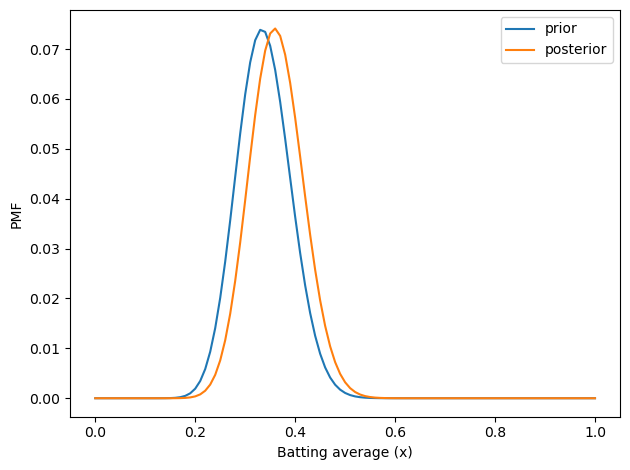

In [55]:
prior2.plot(label='prior')
posterior2.plot(label='posterior')
decorate(xlabel='Batting average (x)', ylabel='PMF')

In [48]:
prior.mean(), posterior2.mean()

(0.33766233766233766, 0.3625)